In [24]:
import sys
from pathlib import Path
import importlib

%load_ext autoreload
%autoreload 2

current = Path.cwd()

if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

import ultrasound_tracker.roi as roi
import ultrasound_tracker.geometry as geom
import ultrasound_tracker.utils as ut
import ultrasound_tracker.ultratimtrack_kalman as utt

roi = importlib.reload(roi)
geom = importlib.reload(geom)
ut = importlib.reload(ut)
utt = importlib.reload(utt)

from ultrasound_tracker.ultratimtrack_kalman import (
    UltraTimTrackKalmanConfig,
    UltraTimTrackGeometricKalman,
    state_from_segment,
    segment_from_state,
    geometry_from_state,
)

print("ROI:", roi.__file__)
print("Geometry:", geom.__file__)
print("Utils:", ut.__file__)
print("UltraTimTrack Kalman:", utt.__file__)

print("UltraTimTrackGeometricKalman OK:", UltraTimTrackGeometricKalman)

ROI: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/roi.py
Geometry: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/geometry.py
Utils: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/utils.py
UltraTimTrack Kalman: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/ultratimtrack_kalman.py
UltraTimTrackGeometricKalman OK: <class 'ultrasound_tracker.ultratimtrack_kalman.UltraTimTrackGeometricKalman'>


In [26]:
VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
ROI_PATH = PROJECT_ROOT / "data" / "rois" / "UltraTimTrack_test_rois.json"

TIMTRACK_NPZ = PROJECT_ROOT / "results" / "timtrack_sequence_features_arrays.npz"
KLT_NPZ = PROJECT_ROOT / "results" / "klt_sequence_features_arrays.npz"

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

OUT_CSV = RESULTS_DIR / "ultratimtrack_geometric_kalman_features.csv"
OUT_NPZ = RESULTS_DIR / "ultratimtrack_geometric_kalman_features_arrays.npz"

print("VIDEO_PATH:", VIDEO_PATH)
print("TIMTRACK_NPZ:", TIMTRACK_NPZ)
print("KLT_NPZ:", KLT_NPZ)
print("OUT_CSV:", OUT_CSV)
print("OUT_NPZ:", OUT_NPZ)

VIDEO_PATH: /Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4
TIMTRACK_NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_features_arrays.npz
KLT_NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/klt_sequence_features_arrays.npz
OUT_CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/ultratimtrack_geometric_kalman_features.csv
OUT_NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/ultratimtrack_geometric_kalman_features_arrays.npz


In [27]:
rois = roi.load_rois(ROI_PATH)

cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)
n_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

ret, frame0 = cap.read()
cap.release()

if not ret:
    raise RuntimeError(f"Could not read video: {VIDEO_PATH}")

if frame0.ndim == 3:
    frame0_gray = cv2.cvtColor(frame0, cv2.COLOR_BGR2GRAY)
else:
    frame0_gray = frame0.copy()

tim = np.load(TIMTRACK_NPZ, allow_pickle=True)
klt = np.load(KLT_NPZ, allow_pickle=True)

print("FPS:", fps)
print("Video frames:", n_video_frames)
print("Frame shape:", frame0_gray.shape)
print("ROIs:", rois)

print("\nTimTrack keys:")
for key in tim.files:
    print(" -", key, tim[key].shape)

print("\nKLT keys:")
for key in klt.files:
    print(" -", key, klt[key].shape)

FPS: 33.341
Video frames: 2667
Frame shape: (562, 706)
ROIs: {'superficial': (15, 21, 690, 42), 'deep': (16, 298, 689, 76), 'fascicle': (17, 65, 686, 226)}

TimTrack keys:
 - frame (2667,)
 - time_s (2667,)
 - success (2667,)
 - sup_apo_lines (2667, 4)
 - deep_apo_lines (2667, 4)
 - fascicle_lines (2667, 4)
 - fascicle_segments (2667, 4)
 - sup_attachments (2667, 2)
 - deep_attachments (2667, 2)
 - fascicle_length_px (2667,)
 - fascicle_angle_deg (2667,)
 - deep_apo_angle_deg (2667,)
 - pennation_angle_deg (2667,)
 - n_fascicle_candidates (2667,)

KLT keys:
 - frame (2667,)
 - time_s (2667,)
 - success (2667,)
 - klt_dx (2667,)
 - klt_dy (2667,)
 - klt_n_points (2667,)
 - klt_affine_used (2667,)
 - sup_apo_lines (2667, 4)
 - deep_apo_lines (2667, 4)
 - fascicle_lines (2667, 4)
 - fascicle_segments (2667, 4)
 - sup_attachments (2667, 2)
 - deep_attachments (2667, 2)
 - fascicle_length_px (2667,)
 - fascicle_angle_deg (2667,)
 - deep_apo_angle_deg (2667,)
 - pennation_angle_deg (2667,)


In [28]:
rois = roi.load_rois(ROI_PATH)

cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)
n_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

ret, frame0 = cap.read()
cap.release()

if not ret:
    raise RuntimeError(f"Could not read video: {VIDEO_PATH}")

if frame0.ndim == 3:
    frame0_gray = cv2.cvtColor(frame0, cv2.COLOR_BGR2GRAY)
else:
    frame0_gray = frame0.copy()

tim = np.load(TIMTRACK_NPZ, allow_pickle=True)
klt = np.load(KLT_NPZ, allow_pickle=True)

print("FPS:", fps)
print("Video frames:", n_video_frames)
print("Frame shape:", frame0_gray.shape)
print("ROIs:", rois)

print("\nTimTrack keys:")
for key in tim.files:
    print(" -", key, tim[key].shape)

print("\nKLT keys:")
for key in klt.files:
    print(" -", key, klt[key].shape)

FPS: 33.341
Video frames: 2667
Frame shape: (562, 706)
ROIs: {'superficial': (15, 21, 690, 42), 'deep': (16, 298, 689, 76), 'fascicle': (17, 65, 686, 226)}

TimTrack keys:
 - frame (2667,)
 - time_s (2667,)
 - success (2667,)
 - sup_apo_lines (2667, 4)
 - deep_apo_lines (2667, 4)
 - fascicle_lines (2667, 4)
 - fascicle_segments (2667, 4)
 - sup_attachments (2667, 2)
 - deep_attachments (2667, 2)
 - fascicle_length_px (2667,)
 - fascicle_angle_deg (2667,)
 - deep_apo_angle_deg (2667,)
 - pennation_angle_deg (2667,)
 - n_fascicle_candidates (2667,)

KLT keys:
 - frame (2667,)
 - time_s (2667,)
 - success (2667,)
 - klt_dx (2667,)
 - klt_dy (2667,)
 - klt_n_points (2667,)
 - klt_affine_used (2667,)
 - sup_apo_lines (2667, 4)
 - deep_apo_lines (2667, 4)
 - fascicle_lines (2667, 4)
 - fascicle_segments (2667, 4)
 - sup_attachments (2667, 2)
 - deep_attachments (2667, 2)
 - fascicle_length_px (2667,)
 - fascicle_angle_deg (2667,)
 - deep_apo_angle_deg (2667,)
 - pennation_angle_deg (2667,)


In [29]:
frames_arr = tim["frame"].astype(int)
time_arr = tim["time_s"].astype(np.float32)

tim_success = tim["success"].astype(bool)
klt_success = klt["success"].astype(bool)

# TimTrack geometry
tim_sup_apo_lines = tim["sup_apo_lines"].astype(np.float32)
tim_deep_apo_lines = tim["deep_apo_lines"].astype(np.float32)
tim_fascicle_lines = tim["fascicle_lines"].astype(np.float32)
tim_fascicle_segments = tim["fascicle_segments"].astype(np.float32)
tim_sup_attachments = tim["sup_attachments"].astype(np.float32)
tim_deep_attachments = tim["deep_attachments"].astype(np.float32)

# KLT geometry
klt_sup_apo_lines = klt["sup_apo_lines"].astype(np.float32)
klt_deep_apo_lines = klt["deep_apo_lines"].astype(np.float32)
klt_fascicle_lines = klt["fascicle_lines"].astype(np.float32)
klt_fascicle_segments = klt["fascicle_segments"].astype(np.float32)
klt_sup_attachments = klt["sup_attachments"].astype(np.float32)
klt_deep_attachments = klt["deep_attachments"].astype(np.float32)

# Numeric values from previous notebooks
tim_length = tim["fascicle_length_px"].astype(np.float32)
tim_fascicle_angle = tim["fascicle_angle_deg"].astype(np.float32)
tim_deep_apo_angle = tim["deep_apo_angle_deg"].astype(np.float32)
tim_pennation = tim["pennation_angle_deg"].astype(np.float32)

klt_length = klt["fascicle_length_px"].astype(np.float32)
klt_fascicle_angle = klt["fascicle_angle_deg"].astype(np.float32)
klt_deep_apo_angle = klt["deep_apo_angle_deg"].astype(np.float32)
klt_pennation = klt["pennation_angle_deg"].astype(np.float32)

print("Number of frames/results:", len(frames_arr))
print("TimTrack success rate:", 100 * np.mean(tim_success), "%")
print("KLT success rate:", 100 * np.mean(klt_success), "%")

Number of frames/results: 2667
TimTrack success rate: 100.0 %
KLT success rate: 100.0 %


In [30]:
n = len(frames_arr)

tim_states = np.full((n, 4), np.nan, dtype=np.float32)
klt_states = np.full((n, 4), np.nan, dtype=np.float32)

for i in range(n):
    if tim_success[i] and np.all(np.isfinite(tim_fascicle_segments[i])):
        tim_states[i] = state_from_segment(tim_fascicle_segments[i])

    if klt_success[i] and np.all(np.isfinite(klt_fascicle_segments[i])):
        klt_states[i] = state_from_segment(klt_fascicle_segments[i])

print("TimTrack valid states:", np.sum(np.all(np.isfinite(tim_states), axis=1)))
print("KLT valid states:", np.sum(np.all(np.isfinite(klt_states), axis=1)))

print("\nExample TimTrack state:")
print(tim_states[np.where(np.all(np.isfinite(tim_states), axis=1))[0][0]])

print("\nState meaning:")
print("[x_sup, y_sup, fascicle_angle_deg, fascicle_length_px]")

TimTrack valid states: 2667
KLT valid states: 2667

Example TimTrack state:
[715.6046    52.798447  18.434952 805.5336  ]

State meaning:
[x_sup, y_sup, fascicle_angle_deg, fascicle_length_px]


In [31]:
config = UltraTimTrackKalmanConfig(
    process_noise_covariance_parameter=0.01,

    measurement_noise_x_sup=100.0,
    measurement_noise_y_sup=25.0,
    measurement_noise_angle=4.0,
    measurement_noise_length=100.0,

    initial_covariance=1000.0,

    process_weight_x_sup=1.0,
    process_weight_y_sup=1.0,
    process_weight_angle=1.0,
    process_weight_length=1.0,

    min_covariance=1e-9,
)

kalman = UltraTimTrackGeometricKalman(config=config)

print(config)

UltraTimTrackKalmanConfig(process_noise_covariance_parameter=0.01, measurement_noise_x_sup=100.0, measurement_noise_y_sup=25.0, measurement_noise_angle=4.0, measurement_noise_length=100.0, initial_covariance=1000.0, process_weight_x_sup=1.0, process_weight_y_sup=1.0, process_weight_angle=1.0, process_weight_length=1.0, min_covariance=1e-09)


In [32]:
utt_success = np.zeros(n, dtype=bool)
utt_error = np.array([""] * n, dtype=object)

utt_states = np.full((n, 4), np.nan, dtype=np.float32)
utt_segments = np.full((n, 4), np.nan, dtype=np.float32)
utt_sup_attachments = np.full((n, 2), np.nan, dtype=np.float32)
utt_deep_attachments = np.full((n, 2), np.nan, dtype=np.float32)

utt_length = np.full(n, np.nan, dtype=np.float32)
utt_fascicle_angle = np.full(n, np.nan, dtype=np.float32)
utt_deep_apo_angle = np.full(n, np.nan, dtype=np.float32)
utt_pennation = np.full(n, np.nan, dtype=np.float32)

utt_uncertainty = np.full((n, 4), np.nan, dtype=np.float32)
utt_gain_diag = np.full((n, 4), np.nan, dtype=np.float32)
utt_innovation_norm = np.full(n, np.nan, dtype=np.float32)

used_timtrack_measurement = np.zeros(n, dtype=bool)
used_klt_prediction = np.zeros(n, dtype=bool)

In [33]:
for i in range(n):
    tim_state = tim_states[i] if np.all(np.isfinite(tim_states[i])) else None
    klt_state = klt_states[i] if np.all(np.isfinite(klt_states[i])) else None

    try:
        state = kalman.step(
            klt_state=klt_state,
            timtrack_state=tim_state,
        )

        used_timtrack_measurement[i] = tim_state is not None
        used_klt_prediction[i] = klt_state is not None

        # Use TimTrack deep aponeurosis line as reference for pennation.
        # Later, this can be replaced by filtered aponeurosis geometry.
        deep_apo_line = None
        if np.all(np.isfinite(tim_deep_apo_lines[i])):
            deep_apo_line = tim_deep_apo_lines[i]

        geom_features = kalman.get_geometry(
            deep_apo_line=deep_apo_line,
        )

        utt_states[i] = state
        utt_segments[i] = geom_features["fascicle_segment_between_apos"]
        utt_sup_attachments[i] = geom_features["sup_attachment"]
        utt_deep_attachments[i] = geom_features["deep_attachment"]

        utt_length[i] = geom_features["fascicle_length_px"]
        utt_fascicle_angle[i] = geom_features["fascicle_angle_deg"]
        utt_deep_apo_angle[i] = geom_features["deep_apo_angle_deg"]
        utt_pennation[i] = geom_features["pennation_angle_deg"]

        utt_uncertainty[i] = kalman.get_uncertainty()

        gain_diag = kalman.get_last_gain_diagonal()
        if gain_diag is not None:
            utt_gain_diag[i] = gain_diag

        if kalman.last_innovation is not None:
            utt_innovation_norm[i] = np.linalg.norm(kalman.last_innovation)

        utt_success[i] = True

    except Exception as exc:
        utt_error[i] = str(exc)

    if (i + 1) % 500 == 0:
        print(f"Processed {i + 1}/{n} | success={np.sum(utt_success)}")

print("Done.")
print("UltraTimTrack-like success:", int(np.sum(utt_success)), "/", n)
print("Success rate:", 100 * np.mean(utt_success), "%")

Processed 500/2667 | success=500
Processed 1000/2667 | success=1000
Processed 1500/2667 | success=1500
Processed 2000/2667 | success=2000
Processed 2500/2667 | success=2500
Done.
UltraTimTrack-like success: 2667 / 2667
Success rate: 100.0 %


In [34]:
utt_results = {
    "frame": frames_arr.tolist(),
    "time_s": time_arr.tolist(),
    "success": utt_success.tolist(),

    "utt_x_sup": utt_states[:, 0].tolist(),
    "utt_y_sup": utt_states[:, 1].tolist(),
    "utt_fascicle_angle_deg": utt_states[:, 2].tolist(),
    "utt_fascicle_length_px": utt_states[:, 3].tolist(),

    "utt_pennation_angle_deg": utt_pennation.tolist(),
    "utt_deep_apo_angle_deg": utt_deep_apo_angle.tolist(),

    "used_timtrack_measurement": used_timtrack_measurement.tolist(),
    "used_klt_prediction": used_klt_prediction.tolist(),

    "unc_x_sup": utt_uncertainty[:, 0].tolist(),
    "unc_y_sup": utt_uncertainty[:, 1].tolist(),
    "unc_angle": utt_uncertainty[:, 2].tolist(),
    "unc_length": utt_uncertainty[:, 3].tolist(),

    "innovation_norm": utt_innovation_norm.tolist(),

    "timtrack_length_px": tim_length.tolist(),
    "timtrack_pennation_angle_deg": tim_pennation.tolist(),
    "klt_length_px": klt_length.tolist(),
    "klt_pennation_angle_deg": klt_pennation.tolist(),

    "error": utt_error.tolist(),
}

ut.save_results(utt_results, str(OUT_CSV))

np.savez(
    OUT_NPZ,
    frame=frames_arr,
    time_s=time_arr,
    success=utt_success,

    utt_states=utt_states,
    utt_segments=utt_segments,
    utt_sup_attachments=utt_sup_attachments,
    utt_deep_attachments=utt_deep_attachments,

    utt_fascicle_length_px=utt_length,
    utt_fascicle_angle_deg=utt_fascicle_angle,
    utt_deep_apo_angle_deg=utt_deep_apo_angle,
    utt_pennation_angle_deg=utt_pennation,

    utt_uncertainty=utt_uncertainty,
    utt_gain_diag=utt_gain_diag,
    utt_innovation_norm=utt_innovation_norm,

    used_timtrack_measurement=used_timtrack_measurement,
    used_klt_prediction=used_klt_prediction,

    timtrack_length_px=tim_length,
    timtrack_pennation_angle_deg=tim_pennation,
    klt_length_px=klt_length,
    klt_pennation_angle_deg=klt_pennation,

    timtrack_segments=tim_fascicle_segments,
    klt_segments=klt_fascicle_segments,
)

print("Saved CSV:", OUT_CSV)
print("Saved NPZ:", OUT_NPZ)

Résultats sauvegardés : /Users/grosbedou/PycharmProjects/NDORMS/results/ultratimtrack_geometric_kalman_features.csv
Saved CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/ultratimtrack_geometric_kalman_features.csv
Saved NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/ultratimtrack_geometric_kalman_features_arrays.npz


In [35]:
print("Total frames:", n)
print("TimTrack success:", int(np.sum(tim_success)))
print("KLT success:", int(np.sum(klt_success)))
print("UltraTimTrack-like success:", int(np.sum(utt_success)))

print("\nLength:")
print("  TimTrack mean:", np.nanmean(tim_length))
print("  KLT mean     :", np.nanmean(klt_length))
print("  UTT mean     :", np.nanmean(utt_length))

print("\nPennation:")
print("  TimTrack mean:", np.nanmean(tim_pennation))
print("  KLT mean     :", np.nanmean(klt_pennation))
print("  UTT mean     :", np.nanmean(utt_pennation))

errors = [e for e in utt_error if e != ""]

print("\nNumber of errors:", len(errors))

if len(errors) > 0:
    unique_errors = {}
    for e in errors:
        unique_errors[e] = unique_errors.get(e, 0) + 1

    for e, count in sorted(unique_errors.items(), key=lambda kv: kv[1], reverse=True)[:10]:
        print(f"{count}x : {e}")

Total frames: 2667
TimTrack success: 2667
KLT success: 2667
UltraTimTrack-like success: 2667

Length:
  TimTrack mean: 762.6471
  KLT mean     : 802.2785
  UTT mean     : 801.86127

Pennation:
  TimTrack mean: 16.012983
  KLT mean     : 20.267447
  UTT mean     : 18.396332

Number of errors: 0


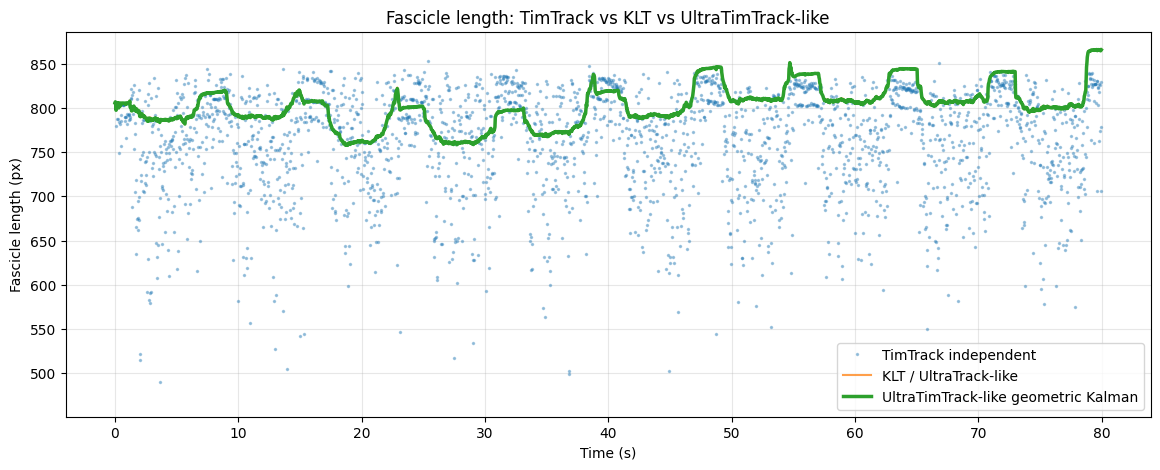

In [36]:
plt.figure(figsize=(14, 5))

plt.plot(time_arr, tim_length, ".", markersize=3, alpha=0.35, label="TimTrack independent")
plt.plot(time_arr, klt_length, "-", linewidth=1.5, alpha=0.75, label="KLT / UltraTrack-like")
plt.plot(time_arr, utt_length, "-", linewidth=2.5, label="UltraTimTrack-like geometric Kalman")

plt.xlabel("Time (s)")
plt.ylabel("Fascicle length (px)")
plt.title("Fascicle length: TimTrack vs KLT vs UltraTimTrack-like")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

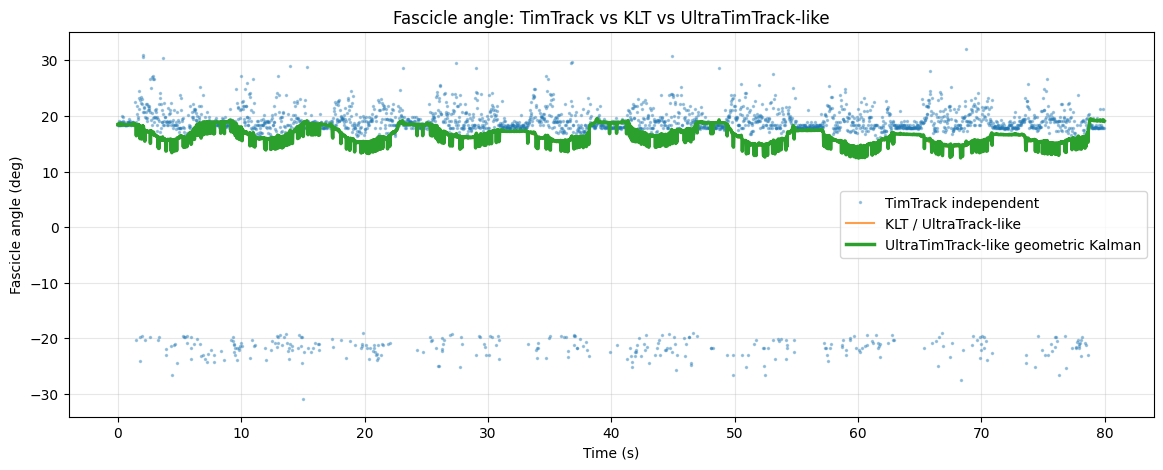

In [37]:
plt.figure(figsize=(14, 5))

plt.plot(time_arr, tim_fascicle_angle, ".", markersize=3, alpha=0.35, label="TimTrack independent")
plt.plot(time_arr, klt_fascicle_angle, "-", linewidth=1.5, alpha=0.75, label="KLT / UltraTrack-like")
plt.plot(time_arr, utt_fascicle_angle, "-", linewidth=2.5, label="UltraTimTrack-like geometric Kalman")

plt.xlabel("Time (s)")
plt.ylabel("Fascicle angle (deg)")
plt.title("Fascicle angle: TimTrack vs KLT vs UltraTimTrack-like")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

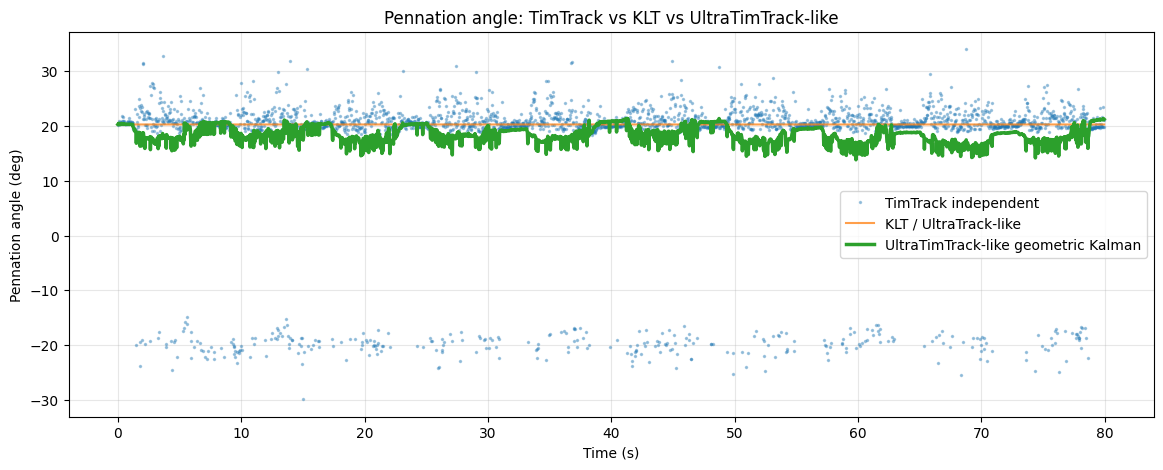

In [38]:
plt.figure(figsize=(14, 5))

plt.plot(time_arr, tim_pennation, ".", markersize=3, alpha=0.35, label="TimTrack independent")
plt.plot(time_arr, klt_pennation, "-", linewidth=1.5, alpha=0.75, label="KLT / UltraTrack-like")
plt.plot(time_arr, utt_pennation, "-", linewidth=2.5, label="UltraTimTrack-like geometric Kalman")

plt.xlabel("Time (s)")
plt.ylabel("Pennation angle (deg)")
plt.title("Pennation angle: TimTrack vs KLT vs UltraTimTrack-like")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

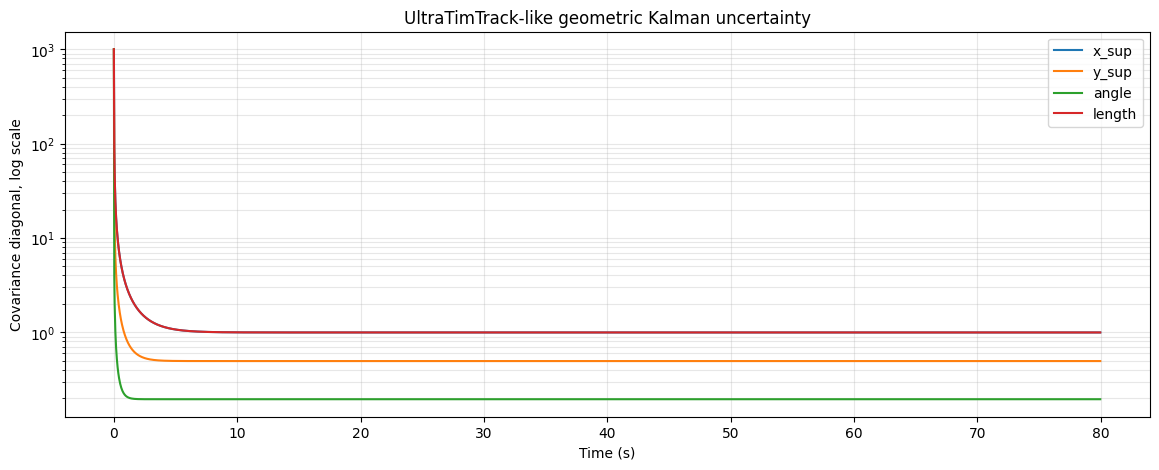

In [39]:
labels = ["x_sup", "y_sup", "angle", "length"]

plt.figure(figsize=(14, 5))

for j, label in enumerate(labels):
    plt.semilogy(time_arr, np.clip(utt_uncertainty[:, j], 1e-12, None), label=label)

plt.xlabel("Time (s)")
plt.ylabel("Covariance diagonal, log scale")
plt.title("UltraTimTrack-like geometric Kalman uncertainty")
plt.legend()
plt.grid(True, alpha=0.3, which="both")
plt.show()

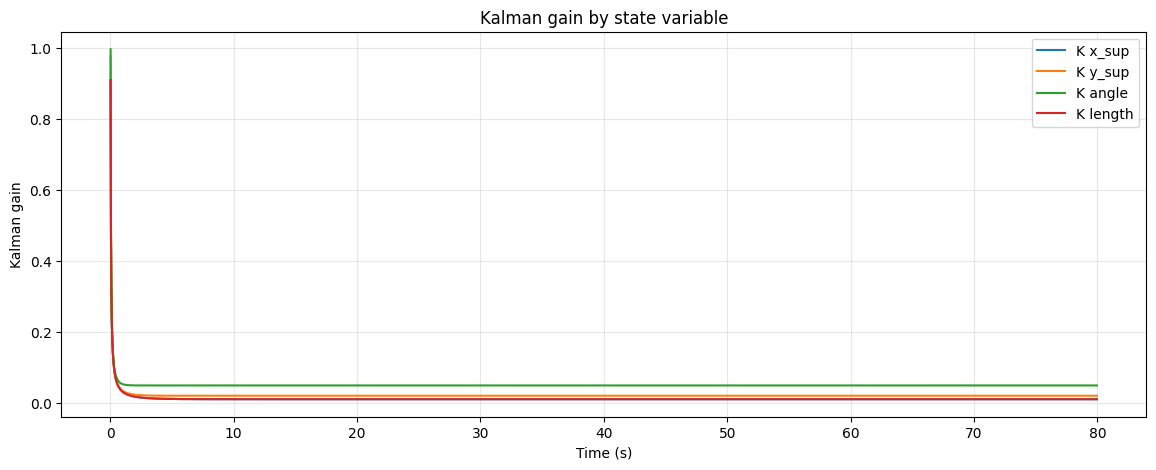

In [40]:
plt.figure(figsize=(14, 5))

for j, label in enumerate(labels):
    plt.plot(time_arr, utt_gain_diag[:, j], label=f"K {label}")

plt.xlabel("Time (s)")
plt.ylabel("Kalman gain")
plt.title("Kalman gain by state variable")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

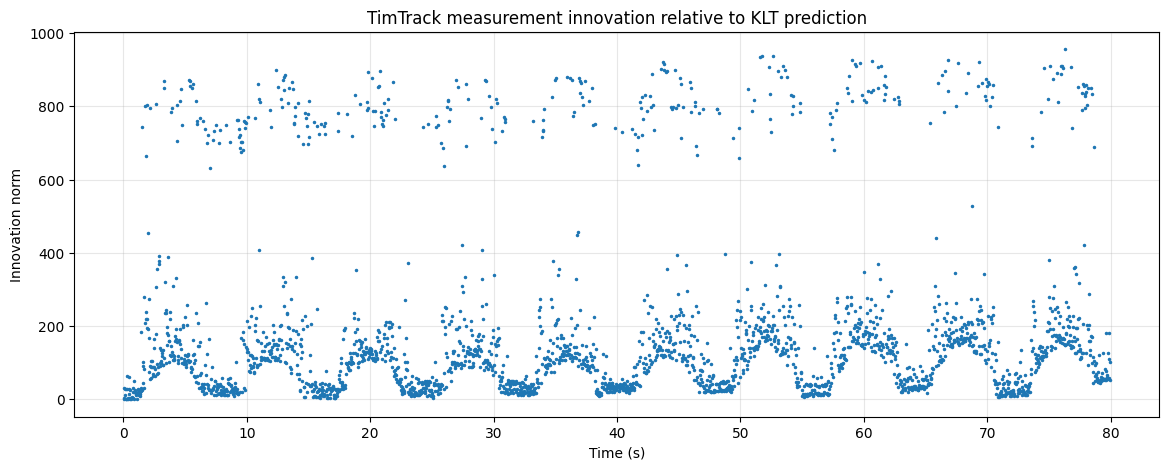

In [41]:
plt.figure(figsize=(14, 5))

plt.plot(time_arr, utt_innovation_norm, ".", markersize=3)
plt.xlabel("Time (s)")
plt.ylabel("Innovation norm")
plt.title("TimTrack measurement innovation relative to KLT prediction")
plt.grid(True, alpha=0.3)
plt.show()

In [42]:
valid_indices = np.where(utt_success)[0]

if len(valid_indices) == 0:
    raise RuntimeError("No successful UltraTimTrack-like frames.")

selected_indices = [
    valid_indices[0],
    valid_indices[len(valid_indices) // 2],
    valid_indices[-1],
]

print("Selected result indices:", selected_indices)
print("Selected frame numbers:", [int(frames_arr[i]) for i in selected_indices])

Selected result indices: [np.int64(0), np.int64(1333), np.int64(2666)]
Selected frame numbers: [0, 1333, 2666]


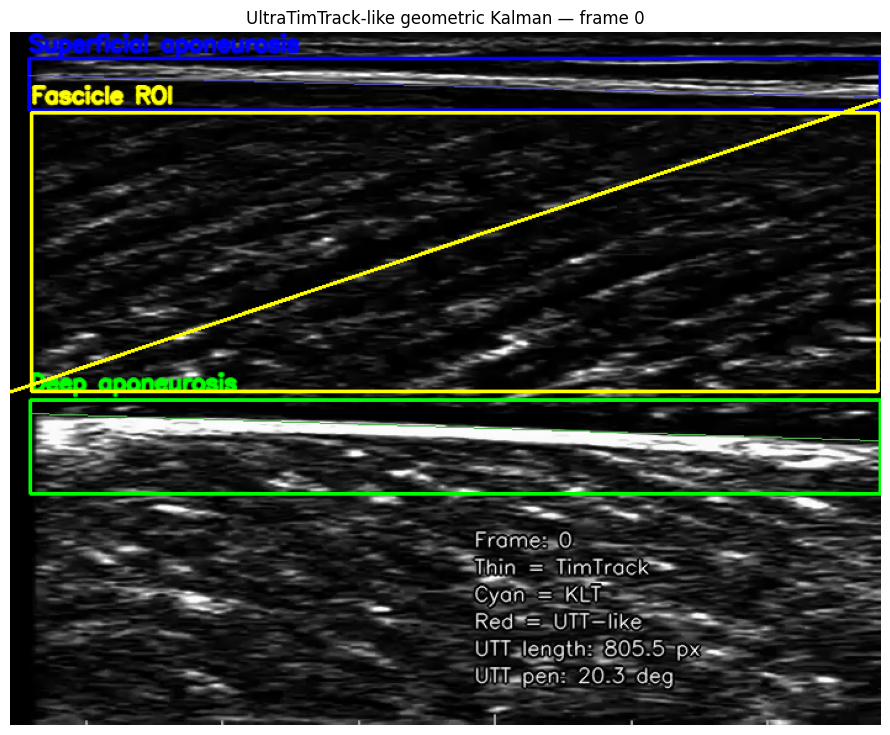

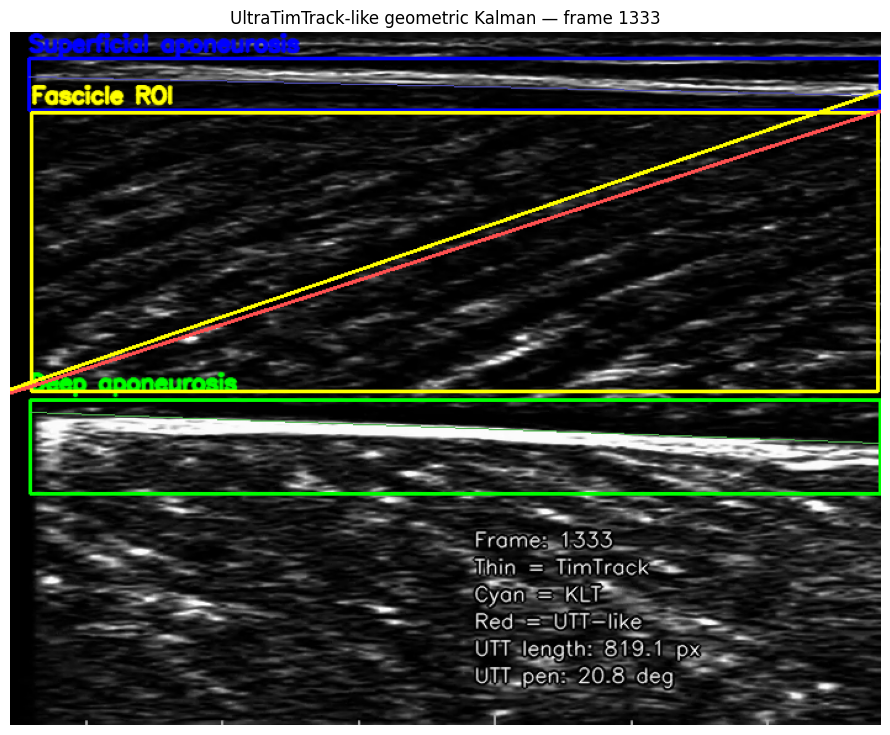

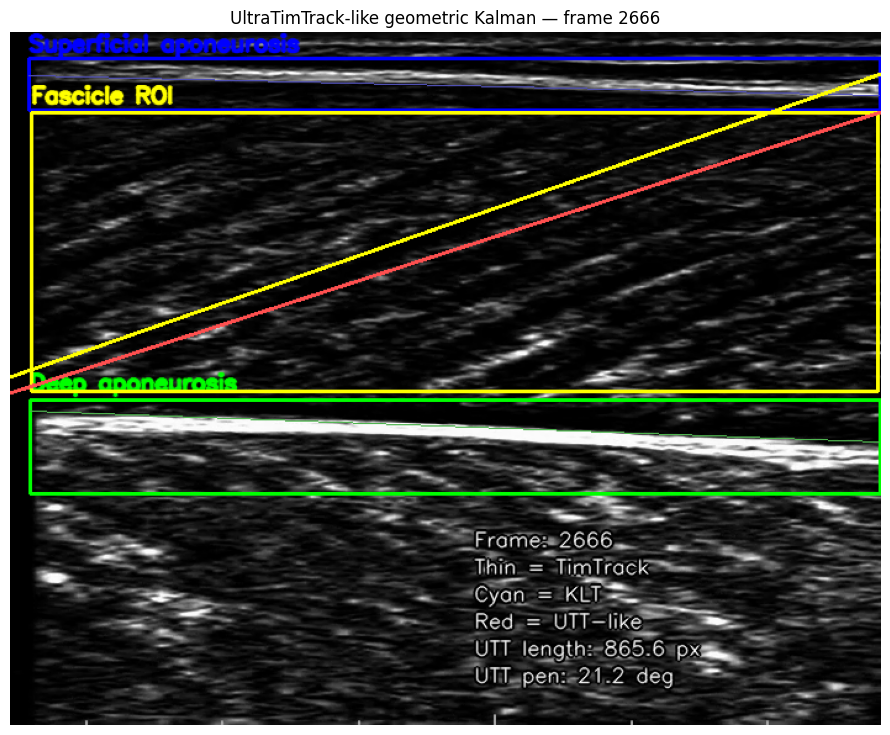

In [43]:
for idx in selected_indices:
    frame_idx = int(frames_arr[idx])

    cap = cv2.VideoCapture(str(VIDEO_PATH))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print("Could not read frame", frame_idx)
        continue

    if frame.ndim == 3:
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        frame_gray = frame.copy()

    vis = roi.draw_rois(frame_gray, rois)

    # TimTrack thin
    ut.draw_line_on_image(vis, tim_sup_apo_lines[idx], color=(180, 80, 80), thickness=1)
    ut.draw_line_on_image(vis, tim_deep_apo_lines[idx], color=(80, 180, 80), thickness=1)
    ut.draw_line_on_image(vis, tim_fascicle_segments[idx], color=(80, 80, 255), thickness=2)

    # KLT medium
    ut.draw_line_on_image(vis, klt_fascicle_segments[idx], color=(0, 255, 255), thickness=2)

    # UltraTimTrack-like thick red
    ut.draw_line_on_image(vis, utt_segments[idx], color=(0, 0, 255), thickness=4)

    ut.draw_points_on_image(
        vis,
        np.vstack([
            utt_sup_attachments[idx],
            utt_deep_attachments[idx],
        ]),
        color=(0, 0, 255),
        radius=6,
    )

    text_lines = [
        f"Frame: {frame_idx}",
        "Thin = TimTrack",
        "Cyan = KLT",
        "Red = UTT-like",
        f"UTT length: {utt_length[idx]:.1f} px",
        f"UTT pen: {utt_pennation[idx]:.1f} deg",
    ]

    ut.put_text_lines_on_image(
        vis,
        text_lines,
        origin=(frame_gray.shape[1] - 330, frame_gray.shape[0] - 145),
        line_spacing=22,
        font_scale=0.55,
        color=(255, 255, 255),
        outline_color=(0, 0, 0),
    )

    plt.figure(figsize=(16, 9))
    plt.imshow(vis[..., ::-1])
    plt.title(f"UltraTimTrack-like geometric Kalman — frame {frame_idx}")
    plt.axis("off")
    plt.show()

In [44]:
loaded_utt = np.load(OUT_NPZ, allow_pickle=True)

print("Loaded:", OUT_NPZ)
print("Keys:")

for key in loaded_utt.files:
    print(" -", key, loaded_utt[key].shape)

print("\nReload check:")
print("Success rate:", 100 * np.mean(loaded_utt["success"]), "%")
print("Mean UTT length:", np.nanmean(loaded_utt["utt_fascicle_length_px"]))
print("Mean UTT pennation:", np.nanmean(loaded_utt["utt_pennation_angle_deg"]))

Loaded: /Users/grosbedou/PycharmProjects/NDORMS/results/ultratimtrack_geometric_kalman_features_arrays.npz
Keys:
 - frame (2667,)
 - time_s (2667,)
 - success (2667,)
 - utt_states (2667, 4)
 - utt_segments (2667, 4)
 - utt_sup_attachments (2667, 2)
 - utt_deep_attachments (2667, 2)
 - utt_fascicle_length_px (2667,)
 - utt_fascicle_angle_deg (2667,)
 - utt_deep_apo_angle_deg (2667,)
 - utt_pennation_angle_deg (2667,)
 - utt_uncertainty (2667, 4)
 - utt_gain_diag (2667, 4)
 - utt_innovation_norm (2667,)
 - used_timtrack_measurement (2667,)
 - used_klt_prediction (2667,)
 - timtrack_length_px (2667,)
 - timtrack_pennation_angle_deg (2667,)
 - klt_length_px (2667,)
 - klt_pennation_angle_deg (2667,)
 - timtrack_segments (2667, 4)
 - klt_segments (2667, 4)

Reload check:
Success rate: 100.0 %
Mean UTT length: 801.86127
Mean UTT pennation: 18.396332


In [45]:
# import json
# import base64
# from pathlib import Path
#
# NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
#
# # Cherche automatiquement le notebook 16
# matches = sorted(NOTEBOOKS_DIR.glob("16*.ipynb"))
#
# if len(matches) == 0:
#     raise FileNotFoundError(f"No notebook starting with '16' found in {NOTEBOOKS_DIR}")
#
# if len(matches) > 1:
#     print("Multiple matches found:")
#     for p in matches:
#         print("-", p.name)
#     raise RuntimeError("Choose the exact notebook name manually.")
#
# NOTEBOOK_PATH = matches[0]
#
# EXPORT_DIR = Path.home() / "Desktop" / "NDORMS_notebook_exports" / NOTEBOOK_PATH.stem
# EXPORT_DIR.mkdir(parents=True, exist_ok=True)
#
# print("Notebook:", NOTEBOOK_PATH)
# print("Export folder:", EXPORT_DIR)
#
# with open(NOTEBOOK_PATH, "r", encoding="utf-8") as f:
#     nb = json.load(f)
#
# image_count = 0
#
# for cell_idx, cell in enumerate(nb.get("cells", []), start=1):
#     for output_idx, output in enumerate(cell.get("outputs", []), start=1):
#         data = output.get("data", {})
#
#         if "image/png" in data:
#             image_count += 1
#
#             img_data = data["image/png"]
#
#             if isinstance(img_data, list):
#                 img_data = "".join(img_data)
#
#             img_bytes = base64.b64decode(img_data)
#
#             out_path = EXPORT_DIR / f"{NOTEBOOK_PATH.stem}_cell_{cell_idx:03d}_output_{output_idx:02d}.png"
#
#             with open(out_path, "wb") as img_file:
#                 img_file.write(img_bytes)
#
#             print("Saved:", out_path)
#
# print(f"\nDone. Exported {image_count} images.")

Notebook: /Users/grosbedou/PycharmProjects/NDORMS/notebooks/16_geometric UltratTimTrack Kalman fusion.ipynb
Export folder: /Users/grosbedou/Desktop/NDORMS_notebook_exports/16_geometric UltratTimTrack Kalman fusion
Saved: /Users/grosbedou/Desktop/NDORMS_notebook_exports/16_geometric UltratTimTrack Kalman fusion/16_geometric UltratTimTrack Kalman fusion_cell_013_output_01.png
Saved: /Users/grosbedou/Desktop/NDORMS_notebook_exports/16_geometric UltratTimTrack Kalman fusion/16_geometric UltratTimTrack Kalman fusion_cell_014_output_01.png
Saved: /Users/grosbedou/Desktop/NDORMS_notebook_exports/16_geometric UltratTimTrack Kalman fusion/16_geometric UltratTimTrack Kalman fusion_cell_015_output_01.png
Saved: /Users/grosbedou/Desktop/NDORMS_notebook_exports/16_geometric UltratTimTrack Kalman fusion/16_geometric UltratTimTrack Kalman fusion_cell_016_output_01.png
Saved: /Users/grosbedou/Desktop/NDORMS_notebook_exports/16_geometric UltratTimTrack Kalman fusion/16_geometric UltratTimTrack Kalman f

In [46]:
labels = ["x_sup", "y_sup", "angle", "length"]

for j, label in enumerate(labels):
    arr = utt_uncertainty[:, j]
    print(f"\n{label}")
    print("min:", np.nanmin(arr))
    print("median:", np.nanmedian(arr))
    print("max:", np.nanmax(arr))
    print("at min_covariance:", np.sum(arr <= 1.01e-9))


x_sup
min: 0.995019
median: 0.995019
max: 1000.0
at min_covariance: 0

y_sup
min: 0.49502626
median: 0.49502626
max: 1000.0
at min_covariance: 0

angle
min: 0.1950626
median: 0.1950626
max: 1000.0
at min_covariance: 0

length
min: 0.995019
median: 0.995019
max: 1000.0
at min_covariance: 0
